In [9]:
import os, pandas as pd, numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os, sys

In [10]:
print(f"Python version: {sys.version}")
print(f"NumPy version:  {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Python version: 3.10.20 | packaged by conda-forge | (main, Mar  5 2026, 17:06:34) [Clang 19.1.7 ]
NumPy version:  2.2.6
Pandas version: 2.3.3


In [11]:
import pltfont # mac 전용 한글 깨짐 라이브러리

# 데이터 불러오기

In [12]:
df_raw =pd.read_csv("/Users/jun/GitStudy/human_A/data/generated_data_from_dabin_0420.csv")

# 데이터 상태 확인

In [13]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129600 entries, 0 to 129599
Data columns (total 47 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   timestamp                     129600 non-null  object 
 1   light_ppfd_umol_m2_s          129600 non-null  float64
 2   air_temp_c                    129600 non-null  float64
 3   relative_humidity_pct         129600 non-null  float64
 4   co2_ppm                       129600 non-null  float64
 5   raw_tank_level_pct            129600 non-null  float64
 6   raw_water_temp_c              129600 non-null  float64
 7   pump_rpm                      129600 non-null  float64
 8   flow_baseline_l_min           129600 non-null  float64
 9   flow_rate_l_min               129600 non-null  float64
 10  suction_pressure_kpa          129600 non-null  float64
 11  discharge_pressure_kpa        129600 non-null  float64
 12  motor_current_a               129600 non-nul

In [14]:
df_raw.describe()

,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_baseline_l_min,flow_rate_l_min,suction_pressure_kpa,...,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph,zone3_flow_l_min,zone3_pressure_kpa,zone3_substrate_moisture_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph,cleaning_event_flag
count,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,...,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000,129600.000000
mean,253.994713,23.242505,72.610537,735.008950,74.122271,19.742272,871.049631,77.994156,38.554317,-5.494169,...,87.934388,60.903072,2.106574,5.829989,12.658151,87.202578,61.188467,2.102862,5.819985,0.002778
std,259.364431,2.247647,7.960082,31.630375,0.137527,1.096417,871.201188,1.533842,38.587723,5.514674,...,2.759555,1.465975,0.033187,0.006026,12.666766,1.841782,1.245588,0.030167,0.006017,0.052632
min,0.000000,19.436000,55.295000,654.626000,73.626000,18.035000,0.000000,73.820000,0.000000,-12.824000,...,83.043000,57.914000,1.975000,5.804000,0.000000,82.567000,58.643000,1.986000,5.792000,0.000000
25%,39.766750,21.593000,64.598750,703.932750,74.028000,18.830000,0.000000,76.677000,0.000000,-10.693000,...,85.971000,60.183000,2.083000,5.826000,0.000000,85.908000,60.426000,2.082000,5.816000,0.000000
50%,90.636500,22.298000,76.882000,752.381500,74.125000,19.216000,846.013500,77.985000,33.930000,-4.992000,...,86.739000,60.936000,2.108000,5.830000,11.332000,86.589000,61.025000,2.104000,5.820000,0.000000
75%,512.331500,25.382000,79.411000,761.039000,74.219000,20.823000,1746.860000,79.320000,77.232000,0.000000,...,90.272000,61.501000,2.130000,5.834000,25.339000,88.539250,61.611000,2.123000,5.824000,0.000000
max,806.744000,28.235000,84.007000,783.025000,74.589000,22.159000,1816.966000,82.511000,82.106000,0.000000,...,98.086000,67.979000,2.213000,5.858000,27.211000,94.560000,67.792000,2.219000,5.849000,1.000000


In [15]:
cat_cols = ["pump_on",
"lights_on",
"ventilation_state",
"dehumidifier_state",
"valve_a_on",
"valve_b_on",
"valve_acid_on",
"zone1_valve_on",
"zone2_valve_on",
"zone3_valve_on"]

#### 데이터 형 변환

In [17]:
# ON은 True로, OFF는 False로 변환
bool_map = {'ON': True, 'OFF': False, '1': True, '0': False, 1: True, 0: False}

# for col in cat_cols:
    #df_raw[col] = df_raw[col].map(bool_map)

# 결과 확인
# print(df_raw[cat_cols].dtypes)

In [18]:
# 타임스탬프 데이터타입으로 변환
df_raw["timestamp"] = pd.to_datetime(df_raw['timestamp'])

In [19]:
# 'id' 컬럼을 인덱스(PK 역할)로 설정
df_raw = df_raw.set_index('timestamp')

# 결측치 확인 

In [20]:
df_raw[df_raw.isnull()].count()

light_ppfd_umol_m2_s            0
air_temp_c                      0
relative_humidity_pct           0
co2_ppm                         0
raw_tank_level_pct              0
raw_water_temp_c                0
pump_rpm                        0
flow_baseline_l_min             0
flow_rate_l_min                 0
suction_pressure_kpa            0
discharge_pressure_kpa          0
motor_current_a                 0
motor_power_kw                  0
bearing_vibration_rms_mm_s      0
motor_temperature_c             0
bearing_temperature_c           0
filter_pressure_in_kpa          0
filter_pressure_out_kpa         0
turbidity_ntu                   0
mix_target_ec_ds_m              0
mix_ec_ds_m                     0
mix_target_ph                   0
mix_ph                          0
mix_temp_c                      0
mix_flow_l_min                  0
dosing_acid_ml_min              0
drain_ec_ds_m                   0
tank_a_level_pct                0
tank_b_level_pct                0
acid_tank_leve

In [21]:
df_raw[df_raw.isnull()].count().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

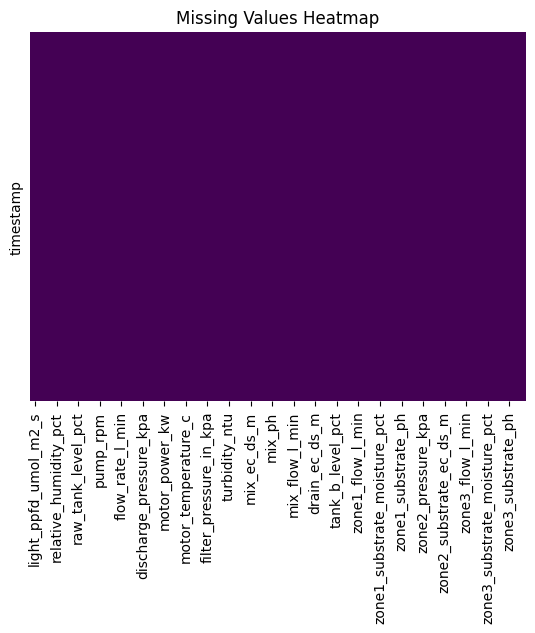

In [22]:
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')

plt.title('Missing Values Heatmap')
plt.show()

# 데이터 상관관계 확인

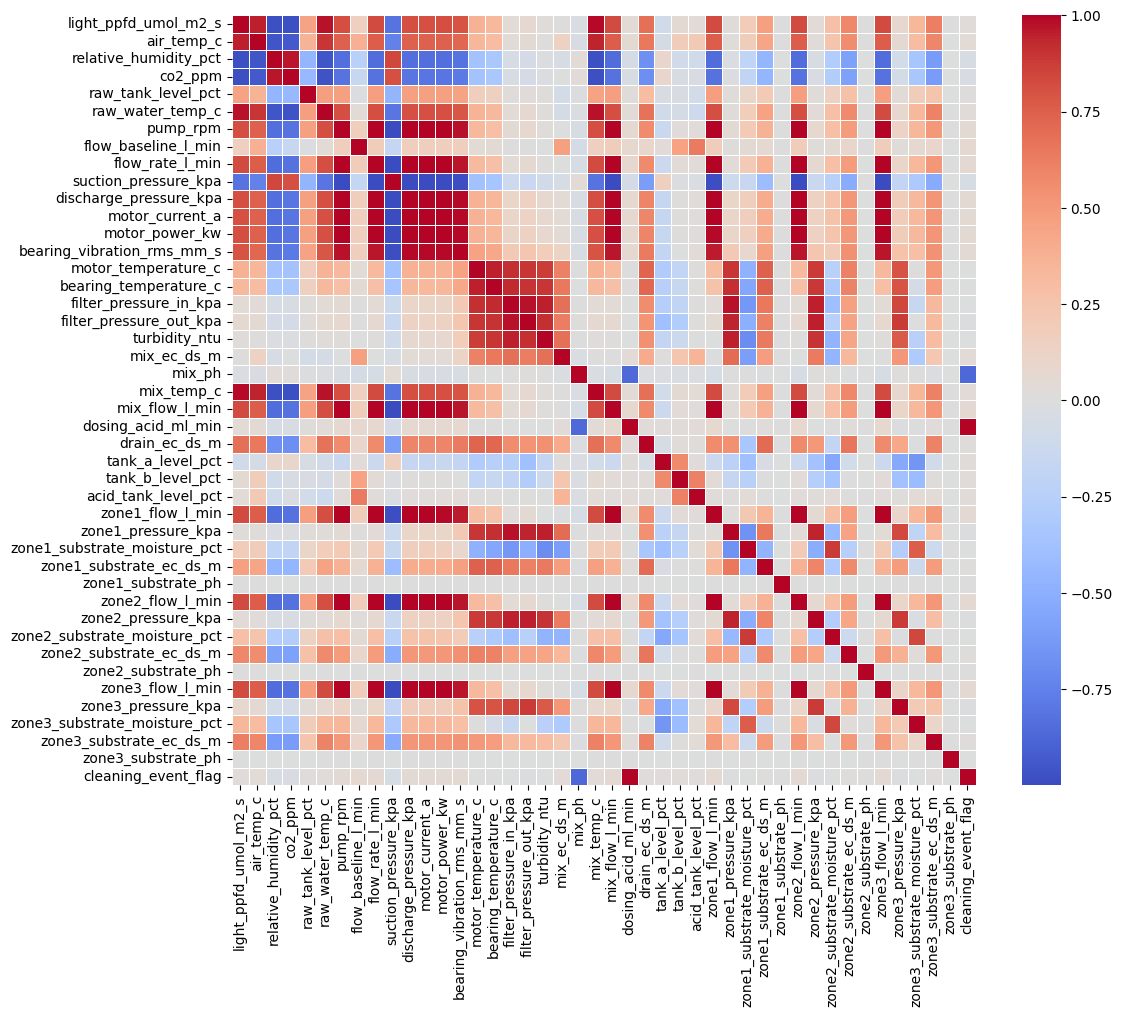

In [23]:
# 상관계수 계산
corr = df_raw.corr(numeric_only=True)

# 특정 기준(예: 상관계수 0.5) 이상의 관계가 하나라도 있는 컬럼만 추출
threshold = 0.5
high_corr_cols = corr.columns[(corr.abs() > threshold).any()]
filtered_corr = corr.loc[high_corr_cols, high_corr_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(filtered_corr, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.show()

In [24]:
# 2. 전체 상관계수 계산 (숫자형 + 수치화된 범주형)
corr_matrix = df_raw.corr(numeric_only=True).abs()

# 3. 상삼각 행렬만 추출
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [25]:
threshold = 0.7
high_corr_pairs = np.where(upper > threshold)

# 쌍(Pair) 리스트 생성
pairs = [(upper.index[i], upper.columns[j], upper.iloc[i, j]) 
        for i, j in zip(*high_corr_pairs)]

# 그룹화 (Dictionary 활용)
groups = {}
for p1, p2, val in pairs:
    if p1 not in groups: groups[p1] = []
    groups[p1].append(f"{p2}({val:.2f})")

print(f"--- [상관계수 {threshold} 이상] 연관 변수 그룹 ---")
if not groups:
    print("기준치를 넘는 고상관 변수가 없습니다.")
else:
    for key, values in groups.items():
        print(f"[{key}] 변수와 중복 위험: {', '.join(values)}\n")

--- [상관계수 0.7 이상] 연관 변수 그룹 ---
[light_ppfd_umol_m2_s] 변수와 중복 위험: air_temp_c(0.95), relative_humidity_pct(0.98), co2_ppm(0.98), raw_water_temp_c(0.97), pump_rpm(0.82), flow_rate_l_min(0.83), suction_pressure_kpa(0.82), discharge_pressure_kpa(0.81), motor_current_a(0.81), motor_power_kw(0.81), bearing_vibration_rms_mm_s(0.79), mix_temp_c(0.99), mix_flow_l_min(0.83), zone1_flow_l_min(0.82), zone2_flow_l_min(0.83), zone3_flow_l_min(0.83)

[air_temp_c] 변수와 중복 위험: relative_humidity_pct(0.95), co2_ppm(0.93), raw_water_temp_c(0.90), pump_rpm(0.75), flow_rate_l_min(0.76), suction_pressure_kpa(0.75), discharge_pressure_kpa(0.75), motor_current_a(0.74), motor_power_kw(0.74), bearing_vibration_rms_mm_s(0.72), mix_temp_c(0.95), mix_flow_l_min(0.76), zone1_flow_l_min(0.76), zone2_flow_l_min(0.76), zone3_flow_l_min(0.76)

[relative_humidity_pct] 변수와 중복 위험: co2_ppm(0.97), raw_water_temp_c(0.95), pump_rpm(0.84), flow_rate_l_min(0.85), suction_pressure_kpa(0.84), discharge_pressure_kpa(0.84), motor_curr

In [26]:
compare_groups = {
    "Flow Rate Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_flow_l_min", "zone2_flow_l_min", "zone3_flow_l_min"
    ],
    "Pressure Comparison (Zone 1 vs 2 vs 3)": [
        "zone1_pressure_kpa", "zone2_pressure_kpa", "zone3_pressure_kpa"
    ],
    "pH Comparison (Raw vs Mix vs Substrate)": [
        "raw_water_ph", "mix_ph", "zone1_substrate_ph", "zone2_substrate_ph", "zone3_substrate_ph"
    ],
    "EC Comparison (Raw vs Mix vs Substrate)": [
        "raw_water_ec_ds_m", "mix_ec_ds_m", "zone1_substrate_ec_ds_m", "zone2_substrate_ec_ds_m", "zone3_substrate_ec_ds_m"
    ],
    "Temperature Comparison": [
        "air_temp_c", "mix_temp_c", "raw_water_temp_c", "motor_temperature_c"
    ],
    "Tank Levels": [
        "raw_tank_level_pct", "tank_a_level_pct", "tank_b_level_pct", "acid_tank_level_pct"
    ],
    "Tank_pressure": [
        "filter_pressure_in_kpa", "filter_pressure_out_kpa","suction_pressure_kpa","discharge_pressure_kpa"
    ]

}

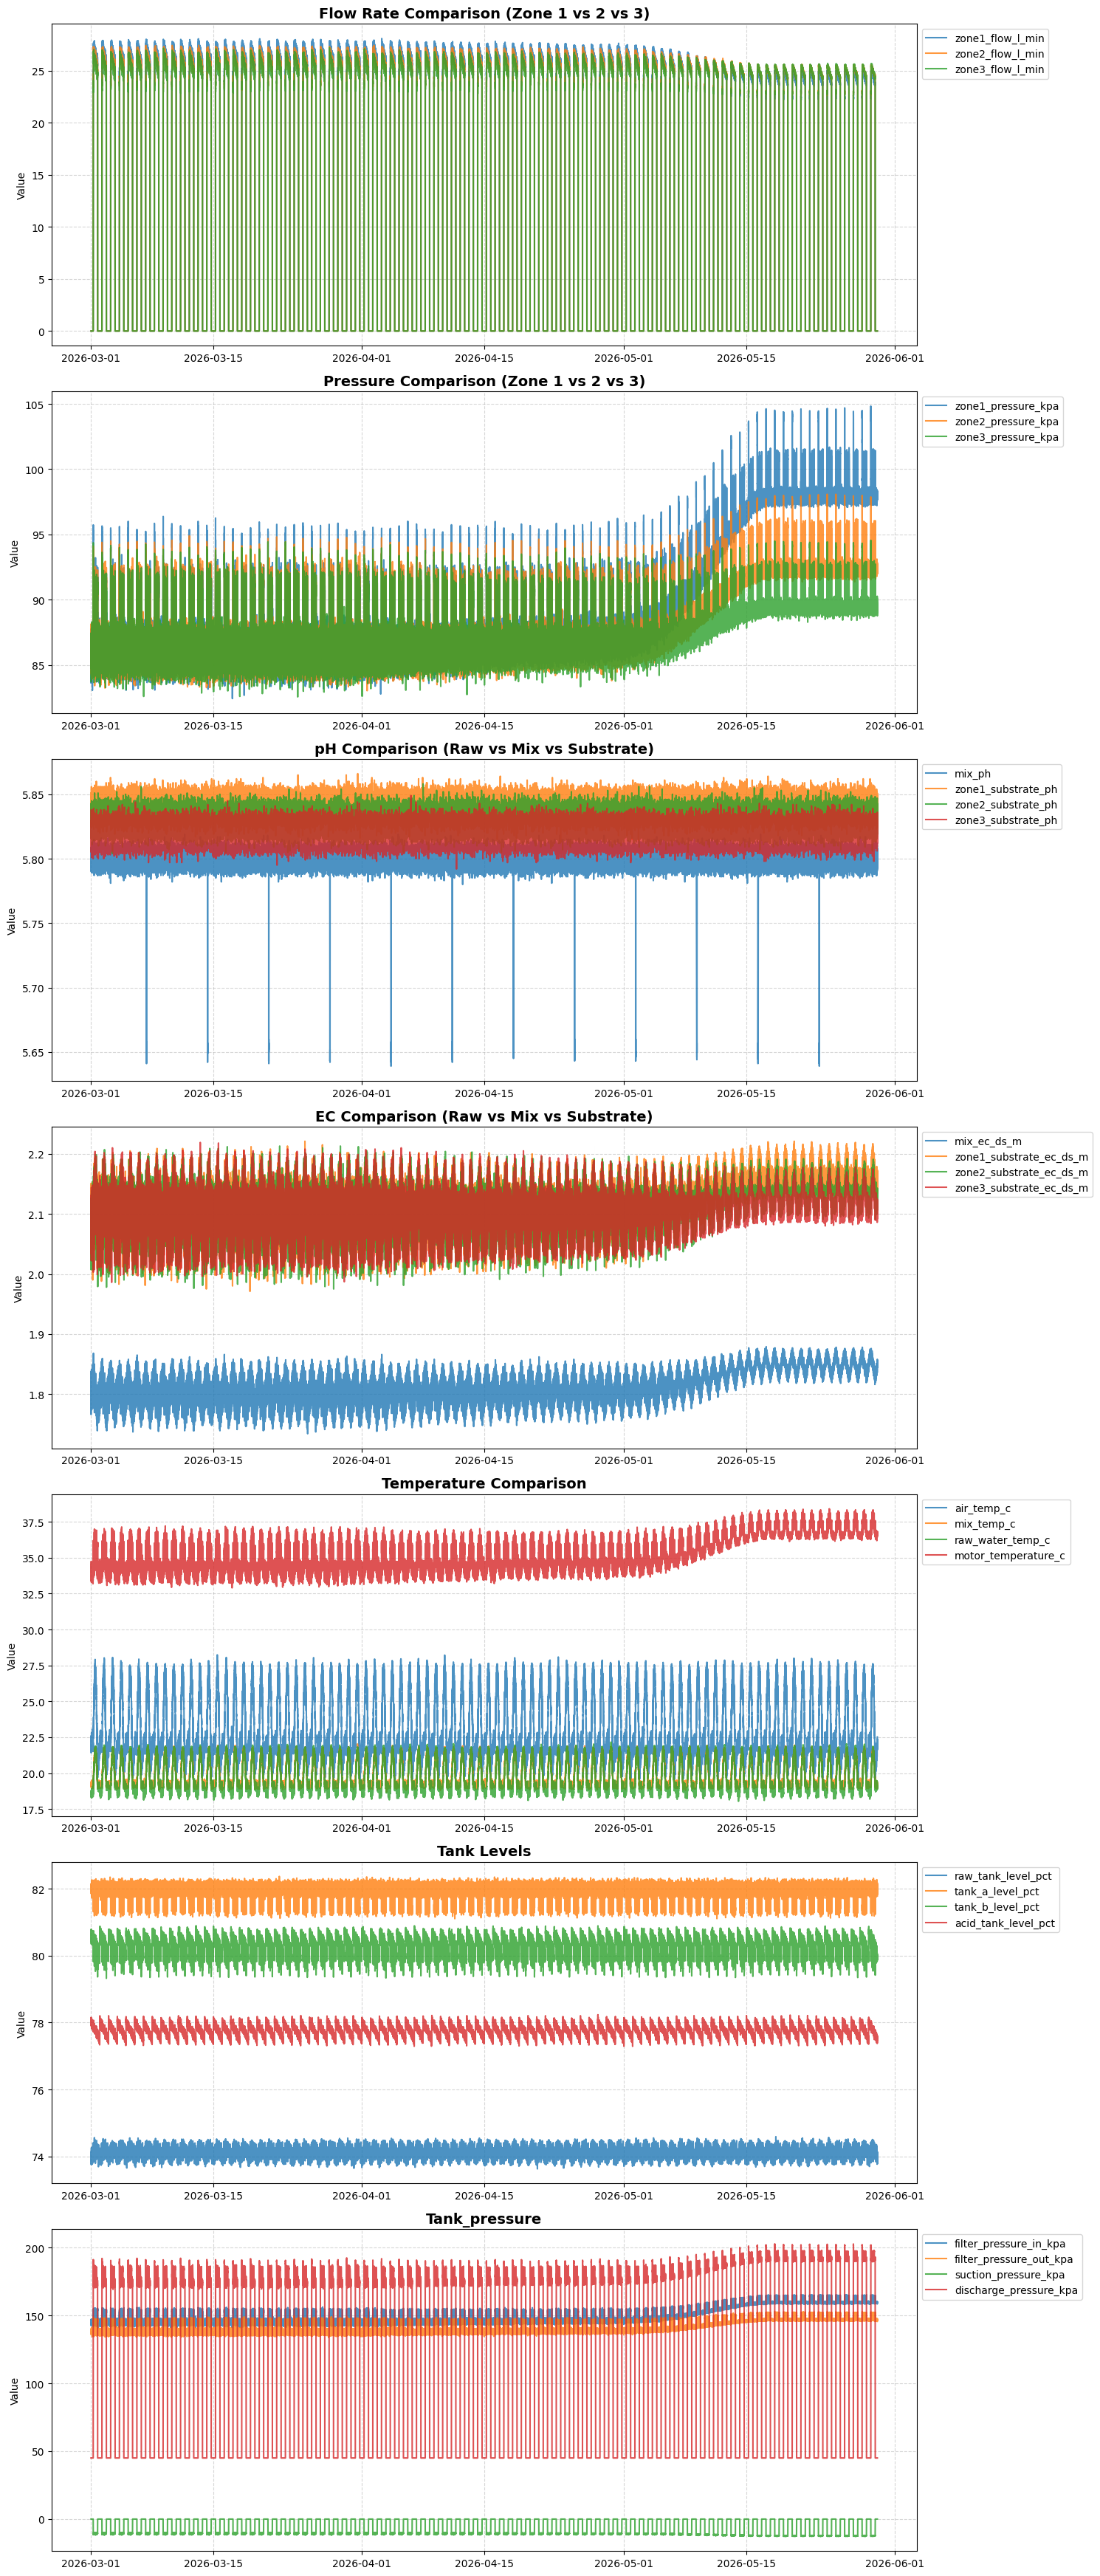

In [27]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
# 10분 간격, 60분, 24시간 이니까  = 6*24
plot_df = df_raw.iloc[:] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

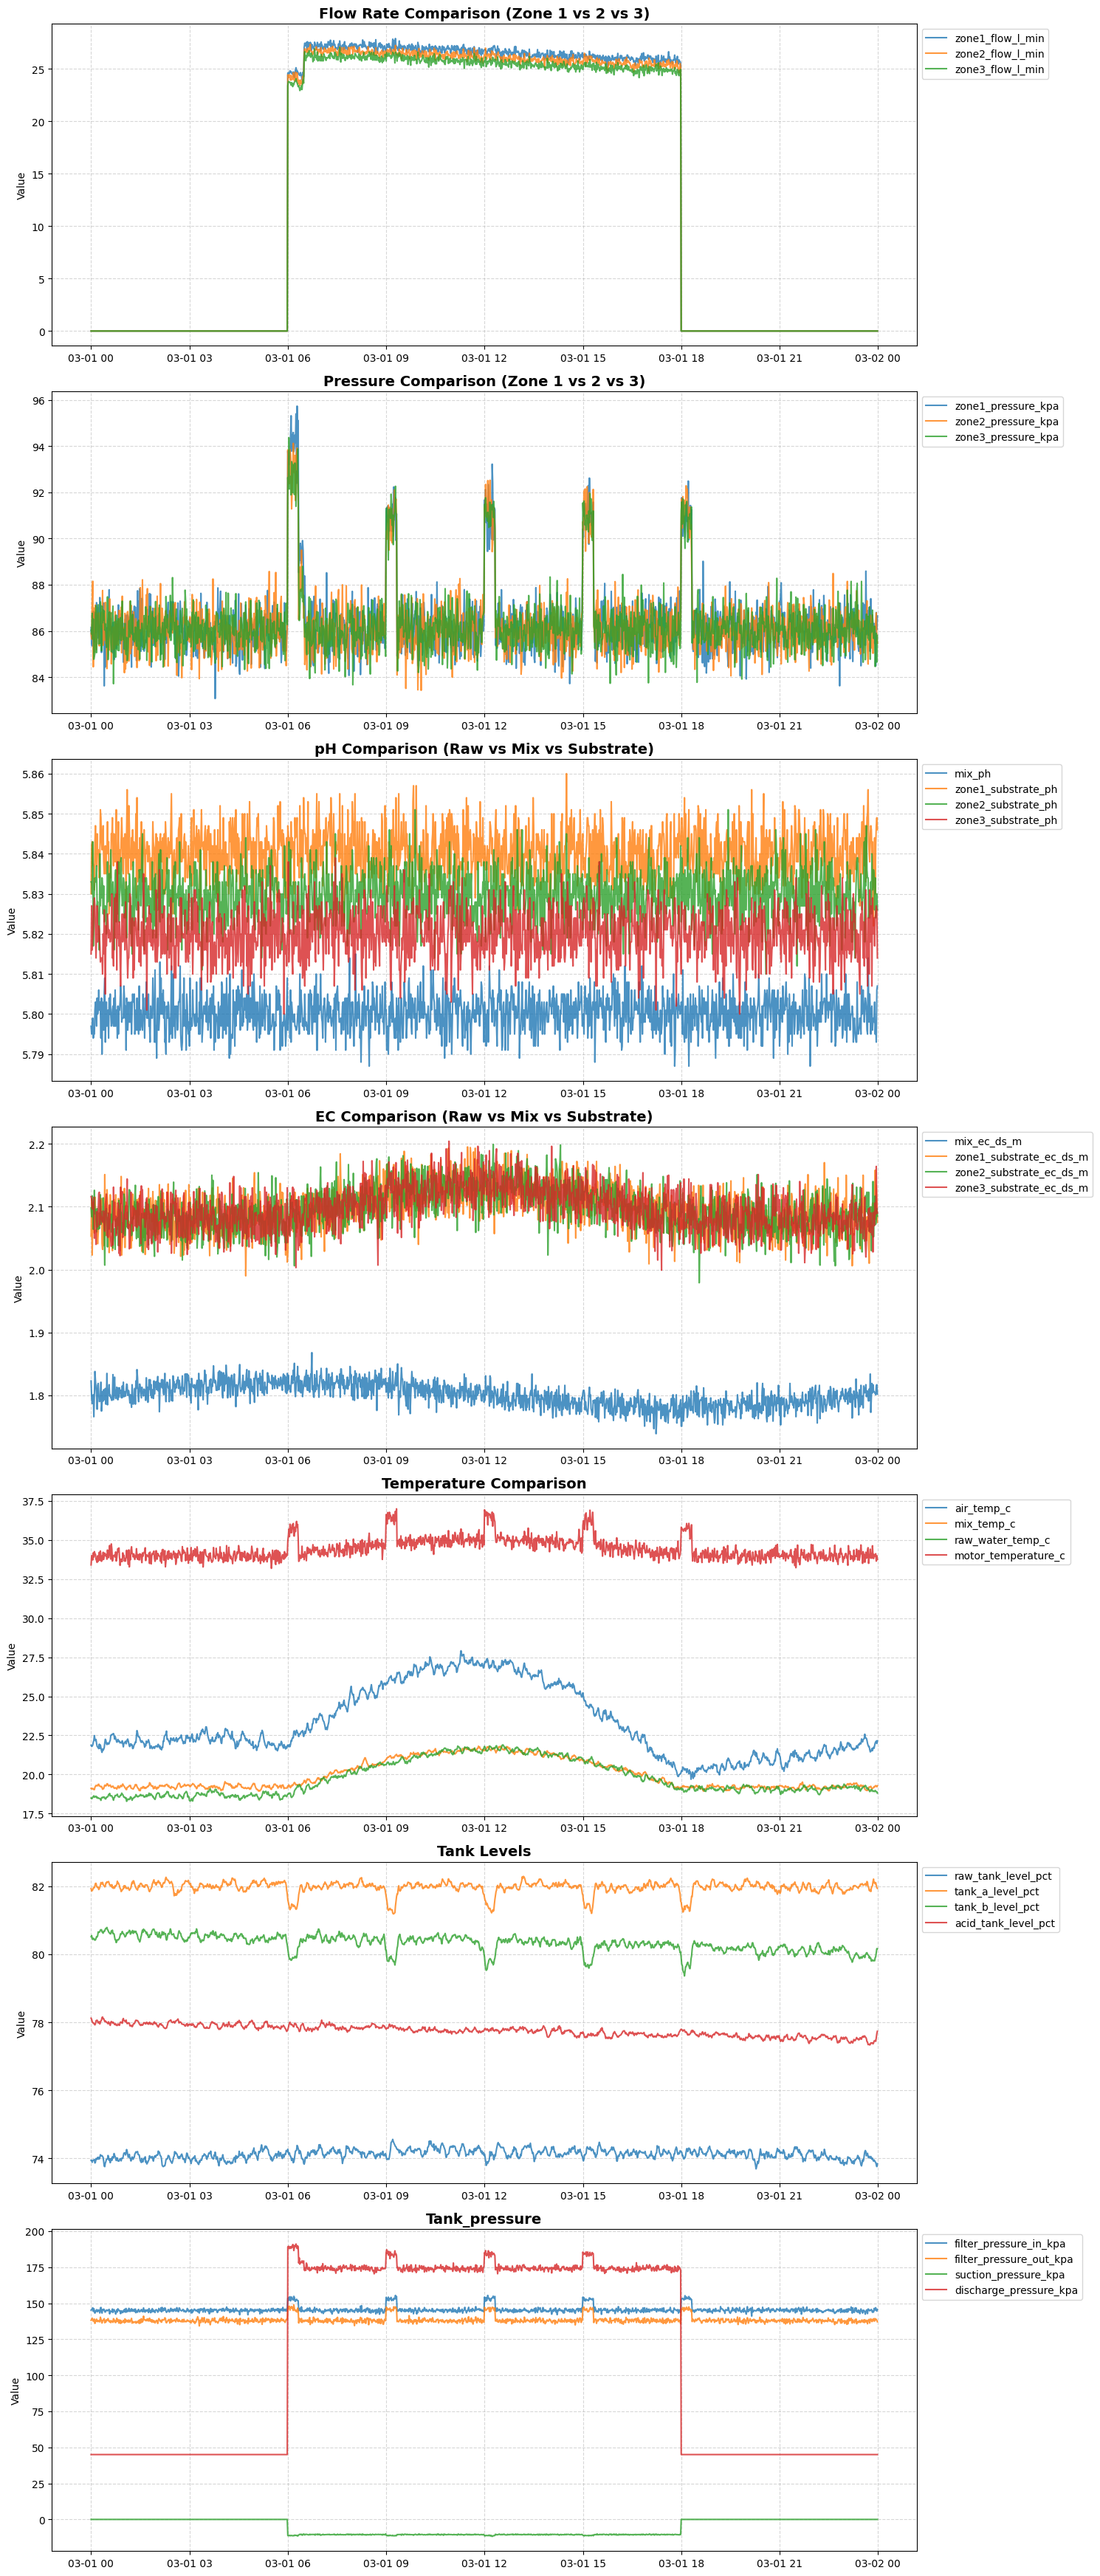

In [28]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))


minute_per_day = 60*24

# 데이터가 너무 많으면 그래프가 무거우니 하루 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

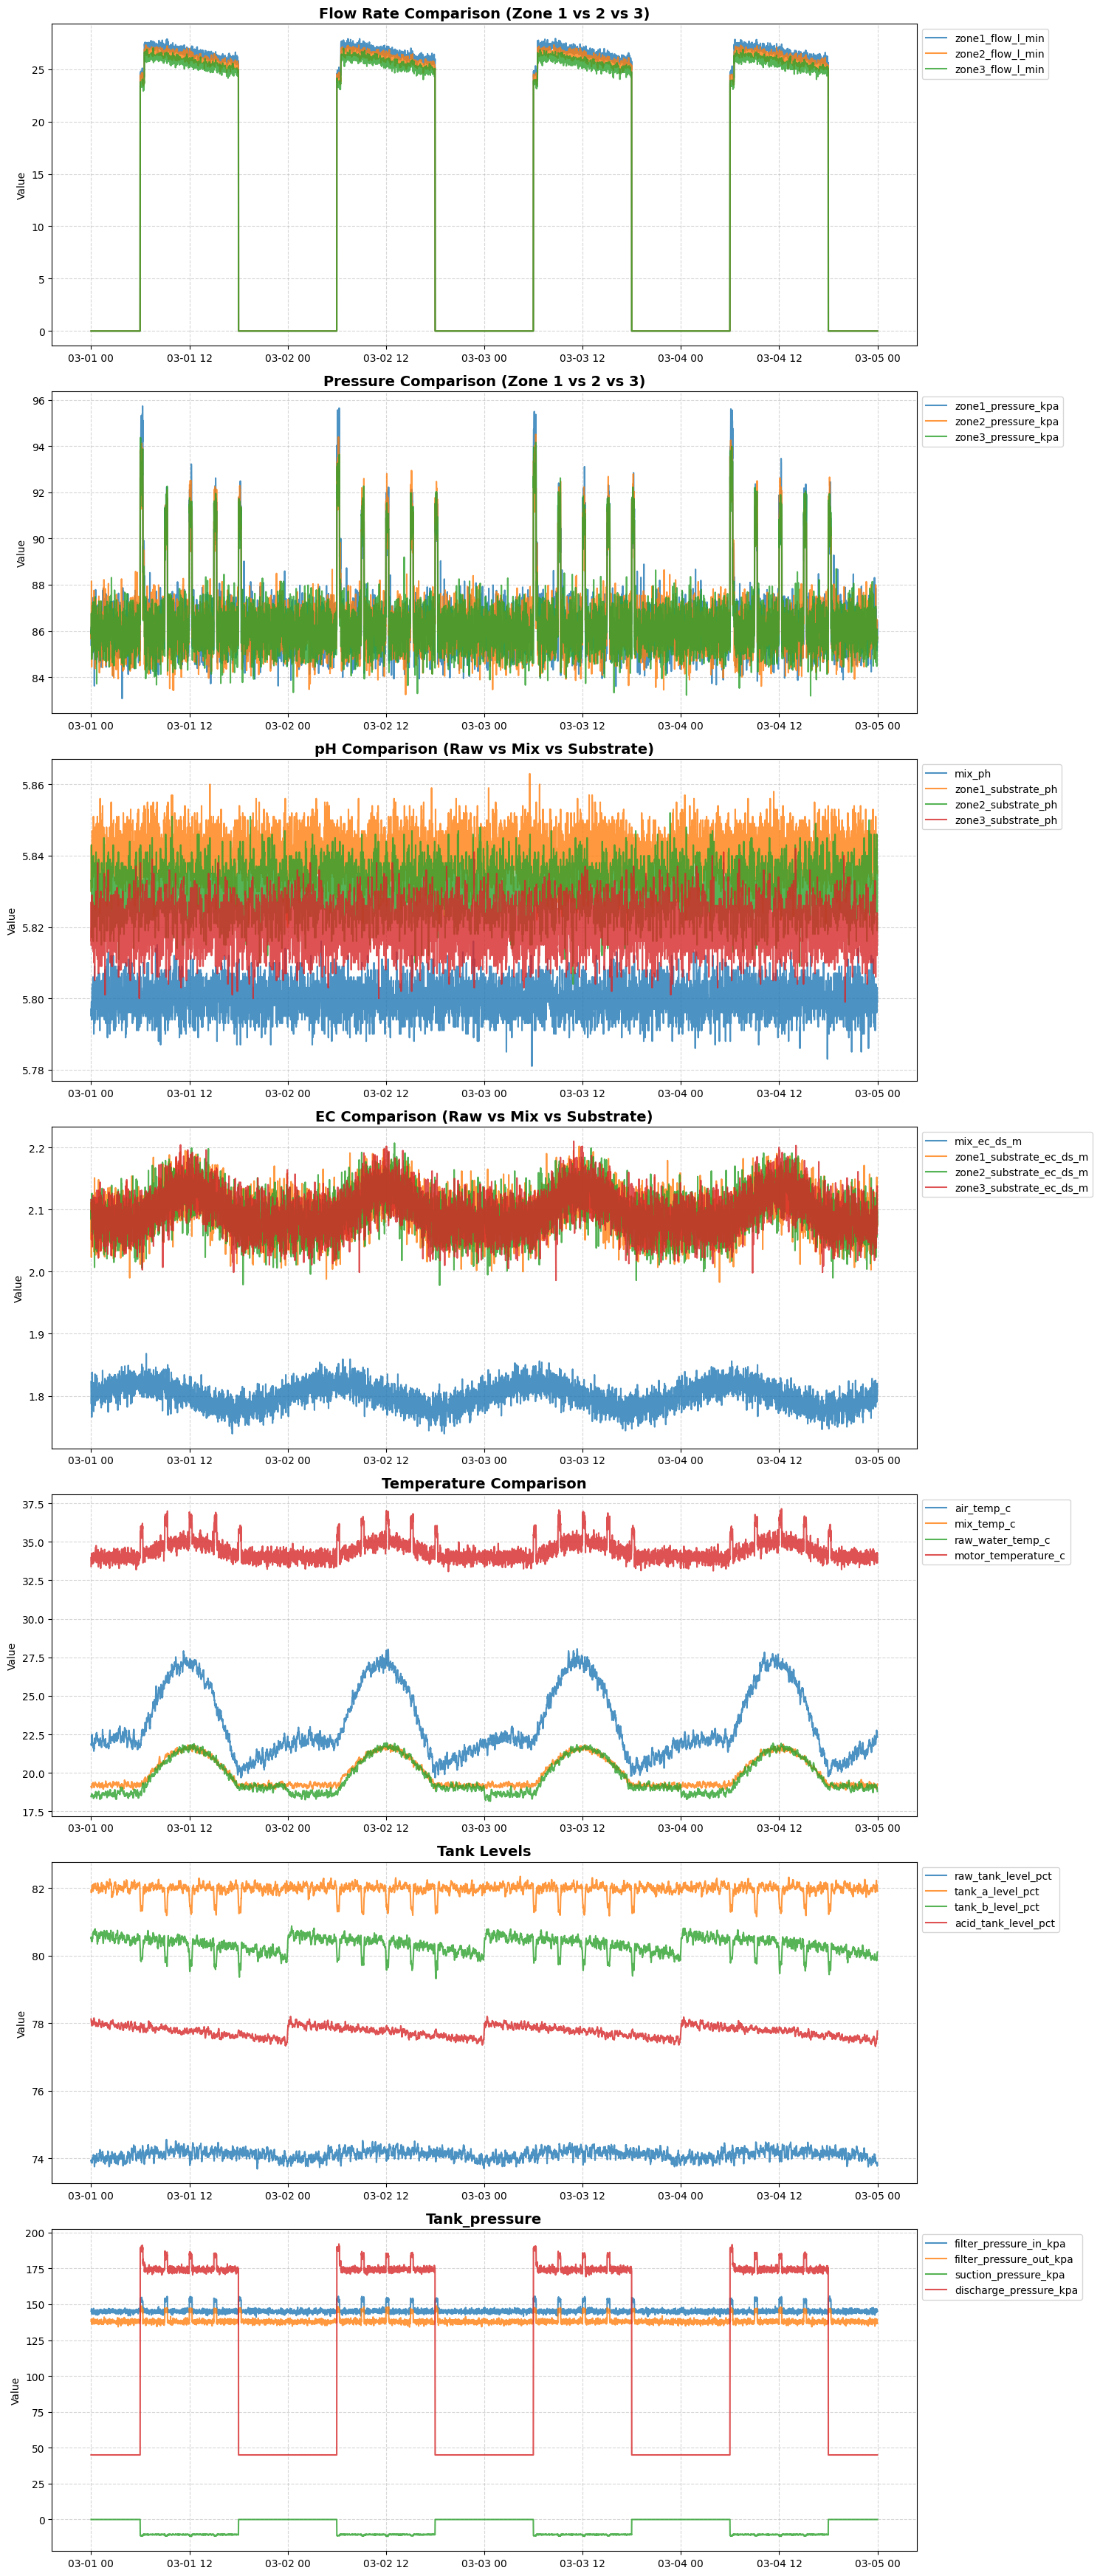

In [29]:
# 시각화 설정
n_groups = len(compare_groups)
fig, axes = plt.subplots(n_groups, 1, figsize=(15, 5 * n_groups))

minute_per_day = 60*24*2

# 이틀 정도만 샘플링해서 보기
plot_df = df_raw.iloc[:minute_per_day*2] 
#plot_df = df_raw

for i, (title, cols) in enumerate(compare_groups.items()):
    ax = axes[i]
    
    # 존재하는 컬럼만 그리기
    valid_cols = [c for c in cols if c in plot_df.columns]
    
    for col in valid_cols:
        ax.plot(plot_df.index, plot_df[col], label=col, alpha=0.8, linewidth=1.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1)) # 범례를 그래프 밖에 표시
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

문제 사항 1 : 지금 밤(딸기 기준)에 유량, 탱크 압력, 모터 온도 등을 보았을 때, 양액이 나가는 걸로 판단되는데, 왜 Zone2, Zone3는 왜 유속이 안 뜨냐?

- 데이터 생성 중 로직 꼬여서 생긴 문제로 판명. 원래는 뿌려주면 안 됨.
- WHY (중요성): 밤에는 식물이 광합성을 멈추고 호흡만 합니다. 이때 뿌리에 물이 너무 많으면 산소가 부족해져 뿌리가 썩는 '습해'가 발생하거나, 증산 작용이 없는 상태에서 세포 내 압력(근압)만 높아져 과실이 터지거나 곰팡이병이 발생할 위험이 큽니다.
  - 새로운 데이터 요청 완료.

# 파생변수 생성

In [30]:
df_copy = df_raw.copy()

In [31]:
df_copy.columns

Index(['light_ppfd_umol_m2_s', 'air_temp_c', 'relative_humidity_pct',
       'co2_ppm', 'raw_tank_level_pct', 'raw_water_temp_c', 'pump_rpm',
       'flow_baseline_l_min', 'flow_rate_l_min', 'suction_pressure_kpa',
       'discharge_pressure_kpa', 'motor_current_a', 'motor_power_kw',
       'bearing_vibration_rms_mm_s', 'motor_temperature_c',
       'bearing_temperature_c', 'filter_pressure_in_kpa',
       'filter_pressure_out_kpa', 'turbidity_ntu', 'mix_target_ec_ds_m',
       'mix_ec_ds_m', 'mix_target_ph', 'mix_ph', 'mix_temp_c',
       'mix_flow_l_min', 'dosing_acid_ml_min', 'drain_ec_ds_m',
       'tank_a_level_pct', 'tank_b_level_pct', 'acid_tank_level_pct',
       'zone1_flow_l_min', 'zone1_pressure_kpa',
       'zone1_substrate_moisture_pct', 'zone1_substrate_ec_ds_m',
       'zone1_substrate_ph', 'zone2_flow_l_min', 'zone2_pressure_kpa',
       'zone2_substrate_moisture_pct', 'zone2_substrate_ec_ds_m',
       'zone2_substrate_ph', 'zone3_flow_l_min', 'zone3_pressure_kpa',
    

---

# 🔁 train.py 파이프라인 재현

`src/train.py`의 학습 파이프라인을 노트북에서 단계별로 재현합니다. 각 단계마다 중간 결과를 확인할 수 있도록 셀을 쪼개 두었습니다.

**파이프라인 구조** (train.py 기준):
1. 데이터 로딩 + 타임스탬프 인덱싱
2. 도메인·타깃 딕셔너리 정의 (motor / hydraulic / nutrient / zone_drip)
3. **전역 SHAP 분석 (고장 신호 탐지 관점)** — `flow_drop_rate` + `filter_delta_p_kpa` 기준
4. **도메인 루프** — 각 도메인마다:
    - Step 1: 윈도우 집계 (`step1_prepare_window_data`)
    - Step 2: 다중공선성 기반 컬럼 드롭 (`step2_clean_and_drop_collinear_dynamic`)
    - Step 3: 타깃별 SHAP 앙상블 (`run_shap_ensemble`)
    - Step 4: AE 학습용 피처 확정 (robust/union)
    - VIP 피처 주입 (time_sin/cos, pump_on, minutes_since_startup)
    - 도메인 필수 센서 주입 (`SENSOR_MANDATORY`)
    - 스케일링 + AutoEncoder 학습
    - Threshold 계산 (MSE 2/3/6σ + 피처별 2/3/6σ)
    - 타깃 기준 프로파일 생성 (`build_target_reference_profiles`)
    - SHAP 아티팩트 payload 조립
    - config JSON 저장


## 1. 모듈 임포트

`src/` 모듈을 직접 참조하므로 `sys.path` 보정이 필요합니다.

In [32]:
import sys, os, json, time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

# src/ 를 import path에 올림
PROJECT_ROOT = Path('/Users/jun/GitStudy/human_A')
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from preprocessing import step1_prepare_window_data, step2_clean_and_drop_collinear_dynamic
from feature_selection import run_shap_ensemble
from feature_engineering import VIP_FEATURES, SENSOR_MANDATORY, inject_vip_features
from inference_core import actionable_feature_mask, build_target_reference_profiles
from model_builder import build_autoencoder
from math_utils import calculate_sigma_thresholds

print('imports ok')


imports ok


/opt/homebrew/Caskroom/miniconda/base/envs/analyzer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. 데이터 로딩

train.py와 동일한 CSV를 읽어 timestamp 인덱스로 설정합니다.

In [33]:
DATA_PATH = PROJECT_ROOT / 'data' / 'generated_data_from_dabin_0420.csv'
df_raw_full = pd.read_csv(DATA_PATH)
df_raw_full['timestamp'] = pd.to_datetime(df_raw_full['timestamp'])
df_raw_full = df_raw_full.set_index('timestamp')
df_raw_full.shape


(129600, 46)

In [34]:
df_raw_full.head()

,light_ppfd_umol_m2_s,air_temp_c,relative_humidity_pct,co2_ppm,raw_tank_level_pct,raw_water_temp_c,pump_rpm,flow_baseline_l_min,flow_rate_l_min,suction_pressure_kpa,...,zone2_pressure_kpa,zone2_substrate_moisture_pct,zone2_substrate_ec_ds_m,zone2_substrate_ph,zone3_flow_l_min,zone3_pressure_kpa,zone3_substrate_moisture_pct,zone3_substrate_ec_ds_m,zone3_substrate_ph,cleaning_event_flag
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-01 00:00:00,64.072,21.870,80.896,743.246,73.943,18.491,0.0,77.807,0.0,0.0,...,85.896,60.764,2.098,5.833,0.0,86.027,60.807,2.116,5.815,0
2026-03-01 00:01:00,8.648,21.793,81.627,751.287,73.943,18.446,0.0,77.707,0.0,0.0,...,85.646,61.113,2.084,5.833,0.0,85.860,61.756,2.112,5.827,0
2026-03-01 00:02:00,22.450,21.810,82.068,752.799,73.884,18.469,0.0,77.585,0.0,0.0,...,87.265,60.283,2.117,5.830,0.0,86.763,61.072,2.099,5.816,0
2026-03-01 00:03:00,10.413,21.883,82.150,747.896,73.936,18.547,0.0,78.878,0.0,0.0,...,88.153,60.149,2.100,5.843,0.0,85.649,61.302,2.096,5.819,0
2026-03-01 00:04:00,9.655,22.062,82.897,747.210,73.950,18.585,0.0,78.369,0.0,0.0,...,84.445,62.249,2.064,5.817,0.0,86.517,60.857,2.102,5.822,0


In [35]:
df_raw_full.index.min(), df_raw_full.index.max()

(Timestamp('2026-03-01 00:00:00'), Timestamp('2026-05-29 23:59:00'))

## 3. 도메인·타깃 딕셔너리

`train.py`의 `subsystem_targets`와 동일. 타깃과 함께 leakage 방지용 'parent columns'를 나열합니다.

In [ ]:
subsystem_targets = {
    'motor': {
        'motor_current_a': ['motor_power_kw', 'motor_temperature_c', 'wire_to_water_efficiency', 'bearing_vibration_rms_mm_s'],
        'rpm_stability_index': ['pump_rpm'],
    },
    'hydraulic': {
        'zone1_resistance': ['zone1_pressure_kpa', 'zone1_flow_l_min'],
        'differential_pressure_kpa': ['discharge_pressure_kpa', 'suction_pressure_kpa'],
    },
    'nutrient': {
        'pid_error_ec': ['mix_ec_ds_m', 'mix_target_ec_ds_m'],
        'salt_accumulation_delta': ['drain_ec_ds_m', 'mix_ec_ds_m'],
    },
    'zone_drip': {
        'zone1_moisture_response_pct': ['zone1_substrate_moisture_pct'],
        'zone1_ec_accumulation': ['zone1_substrate_ec_ds_m', 'mix_ec_ds_m'],
    },
}
{k: list(v.keys()) for k, v in subsystem_targets.items()}


{'motor': ['motor_current_a', 'rpm_stability_index'],
 'hydraulic': ['zone1_resistance', 'differential_pressure_kpa'],
 'nutrient': ['pid_error_ec', 'salt_accumulation_delta'],
 'zone_drip': ['zone1_moisture_response_pct', 'zone1_ec_accumulation']}

---

## 4. 전역 SHAP 분석 — 고장 신호 탐지 관점

개별 도메인 모델을 짜기 **전에**, 전체 시스템에서 고장 신호와 직접 연결되는 두 지표를 타깃으로 SHAP을 돌려 **어떤 센서가 고장 신호를 가장 잘 담고 있는지** 먼저 파악합니다.

### 왜 이 두 타깃인가

| 타깃 | 의미 | 상승 시 해석 |
|---|---|---|
| `flow_drop_rate` | `(baseline - flow) / baseline` | 배관·점적핀 **막힘**으로 유량이 하락 |
| `filter_delta_p_kpa` | `filter_in − filter_out` | 필터 전후 차압 상승 = 필터 **오염** |

둘 다 **이상이 직접 드러나는** 지표라 "이 값을 설명하는 피처"가 곧 "고장 신호를 담고 있는 피처"가 됩니다. 이 전역 분석 결과가 개별 도메인 AE 입력 피처 설계의 **근거**가 됩니다.

### Leakage 방지

각 타깃을 계산하는 데 직접 쓰인 **부모 컬럼**은 입력 피처에서 제외해야 합니다 (그렇지 않으면 RF가 '수식만 학습'하는 누수 발생).
- `flow_drop_rate` ← `flow_rate_l_min`, `flow_baseline_l_min` 제외
- `filter_delta_p_kpa` ← `filter_pressure_in_kpa`, `filter_pressure_out_kpa` 제외

In [ ]:
# 고장 신호 관점 전역 타깃
global_target_dict = {
    'flow_drop_rate':     ['flow_rate_l_min', 'flow_baseline_l_min'],
    'filter_delta_p_kpa': ['filter_pressure_in_kpa', 'filter_pressure_out_kpa'],
}
global_target_dict


### 4-1. 윈도우 집계 + 상관 드롭 (전역)

도메인 루프 때와 동일한 전처리를 전체 데이터에 적용.

In [ ]:
g_target_cols = list(global_target_dict.keys())
df_agg_g, df_interpret_g = step1_prepare_window_data(
    df_raw_full, window_method='sliding', target_cols=g_target_cols
)
df_clean_g = step2_clean_and_drop_collinear_dynamic(
    df_agg_g, corr_threshold=0.85, protected_cols=g_target_cols
)
print(f'df_agg shape:   {df_agg_g.shape}')
print(f'df_clean shape: {df_clean_g.shape} (상관 드롭 후)')


### 4-2. 전역 SHAP 앙상블

⚠️ RF + SHAP이라 수 분 소요. `top_ratio=0.25` — 각 타깃별 상위 25% 피처 추출 후 교집합/robust/union 3가지 집합 반환.

In [ ]:
t0 = time.time()
g_ensemble, g_importance, g_shap_vals, g_X_bg = run_shap_ensemble(
    df_clean_g, global_target_dict, top_ratio=0.25
)
print(f'소요 {time.time()-t0:.1f}s')
print()
print(f'intersection (두 타깃 공통): {len(g_ensemble["intersection"])}개')
print(f'robust       (≥2 타깃):     {len(g_ensemble["robust"])}개')
print(f'union        (둘 중 하나):   {len(g_ensemble["union"])}개')


각 타깃별 SHAP Top 20 (고장 신호 센서 순위):

In [ ]:
for target_name, imp_df in g_importance.items():
    print(f'\n=== {target_name} ===')
    print(imp_df.head(20).to_string(index=False))

### 4-3. 교집합 피처 — "두 고장 지표 모두에 영향을 주는 센서"

이 피처들이 **시스템 수준 핵심 고장 신호**입니다.

In [ ]:
print('intersection (두 타깃 공통 핵심 피처):')
for f in sorted(g_ensemble['intersection']):
    print(f'  - {f}')
print()
print('robust (≥2 타깃 — 실질적으로 intersection과 같음, 타깃 2개라):')
print(g_ensemble['robust'])


### 4-4. 시각화 — 전역 고장 신호 Top 피처

두 타깃의 mean|SHAP|을 합산해 가장 영향력 큰 피처 Top 15를 bar chart로.

In [ ]:
# 두 타깃 SHAP 기여도 합산
combined_imp = {}
for target_name, imp_df in g_importance.items():
    for _, row in imp_df.iterrows():
        feat = row['Feature']
        # 컬럼명이 'Importance' 또는 'mean_abs_shap' 둘 중 하나 → 양쪽 지원
        val = row.get('Importance', row.get('mean_abs_shap', 0))
        combined_imp[feat] = combined_imp.get(feat, 0) + float(val)

top_combined = sorted(combined_imp.items(), key=lambda x: -x[1])[:15]

fig, ax = plt.subplots(figsize=(10, 8))
feats, vals = zip(*top_combined)
ax.barh(range(len(feats)), vals, color='steelblue')
ax.set_yticks(range(len(feats)))
ax.set_yticklabels(feats)
ax.invert_yaxis()
ax.set_xlabel('mean|SHAP| 합산 (flow_drop_rate + filter_delta_p)')
ax.set_title('전역 고장 신호 기여 Top 15 피처')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### 4-5. 해석 및 다음 단계

위에서 Top에 오른 피처들이 **현 데이터셋에서 고장 신호를 가장 잘 담고 있는** 센서·파생변수입니다.

이 분석을 바탕으로:
- 도메인별 `SENSOR_MANDATORY` 리스트 설계 시 우선순위 반영
- AE 입력 피처 선택의 **정당성** 확보 — "우리는 감각이 아니라 SHAP 근거로 피처를 골랐다"
- 다음 §5에서는 도메인별로 다시 SHAP을 돌리지만, 이미 전역 관점에서 핵심 피처가 무엇인지 파악한 상태라 결과 검증이 쉬워짐

---

## 5. 단일 도메인 파이프라인 전개 (중간 결과 확인용)

이 섹션은 **한 도메인을 골라 단계별 출력을 눈으로 확인**하는 용도입니다. 최종 4개 도메인 일괄 실행은 §7 마지막 루프에서 수행합니다.

아래 `SELECTED_DOMAIN` 변수를 `motor` / `hydraulic` / `nutrient` / `zone_drip` 중 바꾸면 다른 도메인으로 재실행 가능합니다.

In [37]:
SELECTED_DOMAIN = 'motor'
target_dict = subsystem_targets[SELECTED_DOMAIN]
print(f'domain = {SELECTED_DOMAIN}')
print(f'targets = {list(target_dict.keys())}')
for t, leaks in target_dict.items():
    print(f'  - {t} (leakage drop: {leaks})')


domain = motor
targets = ['motor_current_a', 'rpm_stability_index']
  - motor_current_a (leakage drop: ['motor_power_kw', 'motor_temperature_c', 'wire_to_water_efficiency', 'bearing_vibration_rms_mm_s'])
  - rpm_stability_index (leakage drop: ['pump_rpm'])


### 5-1. Step 1 — 윈도우 집계

`step1_prepare_window_data`는 전처리(파생변수 생성 + 밤시간 필터) → sliding window 집계까지 수행합니다.
- `df_agg`: 모델 학습용 (raw 센서 + 파생, 윈도우 집계본)
- `df_interpret`: 해석 전용 파생 지표

In [38]:
target_cols = list(target_dict.keys())
df_agg, df_interpret = step1_prepare_window_data(
    df_raw_full, window_method='sliding', target_cols=target_cols
)
print(f'df_agg shape:       {df_agg.shape}')
print(f'df_interpret shape: {df_interpret.shape}')


⏳ [Step 1] 파생변수 생성 및 SLIDING 윈도우 집계 시작...
  -> 집계 완료! (집계 데이터: (129599, 38), 해석용 데이터: (129599, 17))
df_agg shape:       (129599, 38)
df_interpret shape: (129599, 17)


In [39]:
df_agg.head()

,motor_current_a,mix_ec_ds_m,wire_to_water_efficiency,mix_target_ec_ds_m,salt_accumulation_delta,pid_error_ph,flow_roll_mean_10,differential_pressure_kpa,pid_error_ec,pressure_flow_ratio,...,rpm_acc,flow_diff,air_temp_c,pressure_trend_10,temp_slope_c_per_s,pump_on,minutes_since_startup,is_startup_phase,time_sin,time_cos
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-01 00:01:00,0.0,1.8095,0.0,1.8,0.219500,-0.004000,0.0,45.0,0.0095,45000000.0,...,0.0,0.0,21.831500,0.0,0.009967,0,0,0,0.004363,0.999990
2026-03-01 00:02:00,0.0,1.8020,0.0,1.8,0.230667,-0.003667,0.0,45.0,0.0020,45000000.0,...,0.0,0.0,21.824333,0.0,0.004633,0,0,0,0.008727,0.999962
2026-03-01 00:03:00,0.0,1.8015,0.0,1.8,0.229500,-0.003000,0.0,45.0,0.0015,45000000.0,...,0.0,0.0,21.839000,0.0,0.001783,0,0,0,0.013090,0.999914
2026-03-01 00:04:00,0.0,1.8014,0.0,1.8,0.222600,-0.003600,0.0,45.0,0.0014,45000000.0,...,0.0,0.0,21.883600,0.0,0.003213,0,0,0,0.017452,0.999848
2026-03-01 00:05:00,0.0,1.7900,0.0,1.8,0.235600,-0.004000,0.0,45.0,-0.0100,45000000.0,...,0.0,0.0,21.947800,0.0,0.001670,0,0,0,0.021815,0.999762


In [40]:
df_interpret.head()

,pressure_flow_ratio,dp_per_flow,pressure_per_power,flow_per_power,flow_drop_rate,time_sin,time_cos,is_startup_phase,minutes_since_startup,pump_on,pressure_diff,is_pressure_spike,rpm_slope,is_rpm_spike,is_spike,is_startup_spike,is_anomaly_spike
timestamp,,,,,,,,,,,,,,,,,
2026-03-01 00:01:00,45000000.0,45000000.0,45000000.0,0.0,0.0,0.004363,0.999990,0,0,0,0.0,0,0.0,0,0,0,0
2026-03-01 00:02:00,45000000.0,45000000.0,45000000.0,0.0,0.0,0.008727,0.999962,0,0,0,0.0,0,0.0,0,0,0,0
2026-03-01 00:03:00,45000000.0,45000000.0,45000000.0,0.0,0.0,0.013090,0.999914,0,0,0,0.0,0,0.0,0,0,0,0
2026-03-01 00:04:00,45000000.0,45000000.0,45000000.0,0.0,0.0,0.017452,0.999848,0,0,0,0.0,0,0.0,0,0,0,0
2026-03-01 00:05:00,45000000.0,45000000.0,45000000.0,0.0,0.0,0.021815,0.999762,0,0,0,0.0,0,0.0,0,0,0,0


In [41]:
print('df_agg columns:')
print(list(df_agg.columns))


df_agg columns:
['motor_current_a', 'mix_ec_ds_m', 'wire_to_water_efficiency', 'mix_target_ec_ds_m', 'salt_accumulation_delta', 'pid_error_ph', 'flow_roll_mean_10', 'differential_pressure_kpa', 'pid_error_ec', 'pressure_flow_ratio', 'rpm_stability_index', 'motor_temperature_c', 'ph_roll_mean_30', 'pressure_diff', 'mix_ph', 'motor_power_kw', 'flow_rate_l_min', 'ph_trend_30', 'pump_rpm', 'relative_humidity_pct', 'pressure_roll_mean_10', 'rpm_slope', 'mix_target_ph', 'drain_ec_ds_m', 'suction_pressure_kpa', 'flow_trend_10', 'discharge_pressure_kpa', 'flow_drop_rate', 'rpm_acc', 'flow_diff', 'air_temp_c', 'pressure_trend_10', 'temp_slope_c_per_s', 'pump_on', 'minutes_since_startup', 'is_startup_phase', 'time_sin', 'time_cos']


### 5-2. Step 2 — 상관 기반 컬럼 드롭

`corr_threshold=0.85` 초과 쌍에서 한쪽을 제거. `protected_cols`로 타깃은 보호.

In [ ]:
df_clean = step2_clean_and_drop_collinear_dynamic(
    df_agg,
    corr_threshold=0.85,
    protected_cols=list(target_dict.keys()),
)
print(f'df_agg   columns: {df_agg.shape[1]}')
print(f'df_clean columns: {df_clean.shape[1]}')
dropped = sorted(set(df_agg.columns) - set(df_clean.columns))
print(f'drop {len(dropped)}:')
for c in dropped:
    print(f'  - {c}')



🧹 [Step 2] 데이터 정제 및 다중공선성(상관계수 > 0.85) 변수 동적 제거 시작...
  -> 동적 중복/노이즈 변수 11개 제거 완료!
  -> 삭제된 컬럼: ['wire_to_water_efficiency', 'flow_roll_mean_10', 'differential_pressure_kpa', 'pid_error_ec', 'pressure_flow_ratio', 'relative_humidity_pct', 'pressure_roll_mean_10', 'drain_ec_ds_m', 'suction_pressure_kpa', 'flow_diff', 'pressure_trend_10']
  -> 남은 피처 수: 27
df_agg   columns: 38
df_clean columns: 27
drop 11:
  - differential_pressure_kpa
  - drain_ec_ds_m
  - flow_diff
  - flow_roll_mean_10
  - pid_error_ec
  - pressure_flow_ratio
  - pressure_roll_mean_10
  - pressure_trend_10
  - relative_humidity_pct
  - suction_pressure_kpa
  - wire_to_water_efficiency


### 5-3. Step 3 — SHAP 앙상블 (타깃별 Random Forest + SHAP)

각 타깃마다 RF 학습 → SHAP 중요도 계산 → 상위 25% 추출. 전체 타깃의 교집합/robust(≥2)/union 세 가지 전략을 반환합니다.

⚠️ **이 셀은 SHAP 때문에 수 분 걸립니다.**

In [43]:
t0 = time.time()
ensemble_lists, importance_results, shap_vals_dict, X_bg_dict = run_shap_ensemble(
    df_clean, target_dict, top_ratio=0.25
)
print(f'SHAP 앙상블 소요: {time.time() - t0:.1f}s')
print()
print(f'intersection: {len(ensemble_lists["intersection"])}개')
print(f'robust (>=2): {len(ensemble_lists["robust"])}개 ← AE 입력 기본 선택')
print(f'union:        {len(ensemble_lists["union"])}개')


[motor_current_a] 전체 129,599행 | RF샘플 상한=50,000 | 클러스터 상한=200
  -> RF 학습용 50,000행 랜덤 샘플링 완료 (원본 129,599행)
  -> K-Means 배경 압축 중...
  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (6개) 피처 선정 완료

[rpm_stability_index] 전체 129,599행 | RF샘플 상한=50,000 | 클러스터 상한=200
  -> RF 학습용 50,000행 랜덤 샘플링 완료 (원본 129,599행)
  -> K-Means 배경 압축 중...
  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (6개) 피처 선정 완료

🏆 Multi-Target SHAP Ensemble 결과 요약
1. 교집합 (모두에서 중요): 2개
2. 투표(Voting, 2개 이상 타겟에서 중요): 2개  <-- [AutoEncoder 추천]
3. 합집합 (전체 풀): 10개
SHAP 앙상블 소요: 15.8s

intersection: 2개
robust (>=2): 2개 ← AE 입력 기본 선택
union:        10개


각 타깃별 SHAP 중요도 Top 20:

In [44]:
for target_name, imp_df in importance_results.items():
    print(f'\n=== {target_name} ===')
    print(imp_df.head(20).to_string(index=False))



=== motor_current_a ===
                Feature  SHAP_Importance
               pump_rpm         1.378334
        flow_rate_l_min         1.000014
 discharge_pressure_kpa         0.895565
               time_sin         0.005930
  minutes_since_startup         0.004941
            mix_ec_ds_m         0.002969
              rpm_slope         0.002132
    rpm_stability_index         0.001620
          flow_trend_10         0.001579
               time_cos         0.001498
             air_temp_c         0.001389
                rpm_acc         0.001304
          pressure_diff         0.001109
salt_accumulation_delta         0.000849
     temp_slope_c_per_s         0.000501
         flow_drop_rate         0.000496
        ph_roll_mean_30         0.000364
            ph_trend_30         0.000259
                 mix_ph         0.000154
           pid_error_ph         0.000136

=== rpm_stability_index ===
                Feature  SHAP_Importance
       is_startup_phase         0.117668
   

In [45]:
print('robust (>=2 targets 공통):')
print(ensemble_lists['robust'])


robust (>=2 targets 공통):
['time_sin', 'minutes_since_startup']


### 5-4. Step 4 — AE 학습용 X_train_ae 확정

robust가 비어있으면 union으로 폴백.

In [46]:
selected = ensemble_lists['robust'] if ensemble_lists['robust'] else ensemble_lists['union']
if not selected:
    raise ValueError('SHAP 앙상블 결과 피처가 0개입니다.')
X_train_ae = df_clean[selected].copy()
print(f'선택된 피처 {len(selected)}개')
print(f'X_train_ae shape: {X_train_ae.shape}')
X_train_ae.head()


선택된 피처 2개
X_train_ae shape: (129599, 2)


,time_sin,minutes_since_startup
timestamp,,
2026-03-01 00:01:00,0.004363,0
2026-03-01 00:02:00,0.008727,0
2026-03-01 00:03:00,0.013090,0
2026-03-01 00:04:00,0.017452,0
2026-03-01 00:05:00,0.021815,0


### 5-5. VIP 피처 강제 주입

`time_sin`, `time_cos`, `pump_on`, `minutes_since_startup`은 SHAP이 골라주지 않아도 AE가 **기동/정지 맥락**을 학습할 수 있도록 강제 포함.

In [47]:
X_train_ae, injected_vips = inject_vip_features(
    X_train_ae, df_interpret, VIP_FEATURES
)
print(f'VIP 주입: {injected_vips}')
print(f'X_train_ae shape: {X_train_ae.shape}')


VIP 주입: ['time_cos', 'pump_on']
X_train_ae shape: (129599, 4)


### 5-6. 도메인별 필수 센서 강제 주입

`SENSOR_MANDATORY`는 `src/feature_engineering.py`에 도메인별로 정의됨. SHAP robust가 0개 뽑아도 실센서가 AE 입력에 반드시 포함되도록 보장.

In [48]:
mandatory_sensors = SENSOR_MANDATORY.get(SELECTED_DOMAIN, [])
print(f'{SELECTED_DOMAIN} mandatory: {mandatory_sensors}')
X_train_ae, injected_sensors = inject_vip_features(
    X_train_ae, df_agg, mandatory_sensors
)
print(f'실제 주입: {injected_sensors}')
missing = [s for s in mandatory_sensors if s not in X_train_ae.columns]
if missing:
    print(f'⚠️  df_agg에 없는 피처: {missing}')
print(f'최종 X_train_ae shape: {X_train_ae.shape}')
print(f'최종 columns: {list(X_train_ae.columns)}')


motor mandatory: ['motor_power_kw', 'motor_temperature_c', 'bearing_vibration_rms_mm_s', 'bearing_temperature_c', 'wire_to_water_efficiency', 'pump_rpm', 'rpm_slope', 'temp_slope_c_per_s']
실제 주입: ['motor_power_kw', 'motor_temperature_c', 'wire_to_water_efficiency', 'pump_rpm', 'rpm_slope', 'temp_slope_c_per_s']
⚠️  df_agg에 없는 피처: ['bearing_vibration_rms_mm_s', 'bearing_temperature_c']
최종 X_train_ae shape: (129599, 10)
최종 columns: ['time_sin', 'minutes_since_startup', 'time_cos', 'pump_on', 'motor_power_kw', 'motor_temperature_c', 'wire_to_water_efficiency', 'pump_rpm', 'rpm_slope', 'temp_slope_c_per_s']


### 5-7. 스케일링 (MinMaxScaler)

In [49]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_train_ae)
print(f'X_scaled shape: {X_scaled.shape}')
print(f'X_scaled min:   {X_scaled.min():.4f}')
print(f'X_scaled max:   {X_scaled.max():.4f}')


X_scaled shape: (129599, 10)
X_scaled min:   0.0000
X_scaled max:   1.0000


### 5-8. AutoEncoder 모델 구조

In [50]:
autoencoder = build_autoencoder(input_dim=X_scaled.shape[1])
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,902 (7.43 KB)

 Trainable params: 1,902 (7.43 KB)

 Non-trainable params: 0 (0.00 B)

### 5-9. AE 학습 (EarlyStopping patience=10, epochs=100)

⚠️ **수 분 소요**. `verbose=1`이라 epoch 진행바가 줄줄이 찍힙니다.

In [51]:
t0 = time.time()
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1,
)
print(f'학습 소요: {time.time() - t0:.1f}s (epochs={len(history.history["loss"])})')


Epoch 1/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 2s 637us/step - loss: 0.0099 - val_loss: 0.0204
Epoch 2/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - loss: 0.0020 - val_loss: 0.0151
Epoch 3/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 550us/step - loss: 0.0017 - val_loss: 0.0118
Epoch 4/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 560us/step - loss: 0.0013 - val_loss: 0.0044
Epoch 5/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 532us/step - loss: 0.0010 - val_loss: 0.0027
Epoch 6/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 525us/step - loss: 9.0039e-04 - val_loss: 0.0017
Epoch 7/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - loss: 7.6280e-04 - val_loss: 0.0012
Epoch 8/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 540us/step - loss: 5.7072e-04 - val_loss: 0.0011
Epoch 9/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 536us/step - loss: 4.7973e-04 - val_loss: 0.0011
Epoch 10/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 534us/step - loss: 4.4084e-04 - val_loss: 9.6154e-04
Epoch 11/100
1620/1620 ━━━━━━━━━━━━━━━━━━━━ 1s 504us/step - loss:

Loss 곡선:

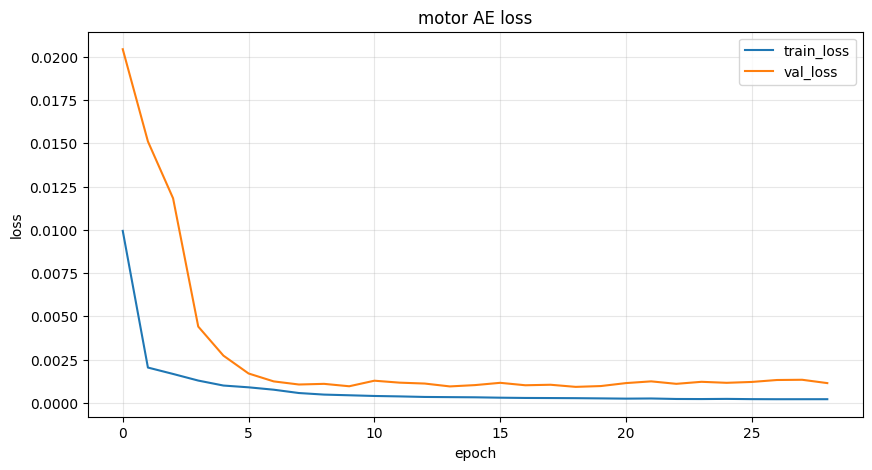

In [52]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history['loss'], label='train_loss')
ax.plot(history.history['val_loss'], label='val_loss')
ax.set_xlabel('epoch'); ax.set_ylabel('loss'); ax.set_title(f'{SELECTED_DOMAIN} AE loss')
ax.legend(); ax.grid(alpha=0.3); plt.show()


### 5-10. MSE 임계값 계산 (컨텍스트 피처 제외)

`actionable_feature_mask`로 `time_sin/cos`, `pump_on`, `minutes_since_startup` 등 컨텍스트 피처를 MSE 산출에서 제외 (RCA와 동일한 기준).

In [53]:
reconstructed = autoencoder.predict(X_scaled)
sq_err = np.power(X_scaled - reconstructed, 2)

feature_cols = X_train_ae.columns.tolist()
scoring_mask = actionable_feature_mask(feature_cols)
if scoring_mask.sum() == 0:
    print('⚠️ 모든 피처가 컨텍스트 — 전체로 폴백')
    scoring_mask = np.ones(len(feature_cols), dtype=bool)
scoring_features = [f for f, keep in zip(feature_cols, scoring_mask) if keep]
print(f'scoring features ({len(scoring_features)}/{len(feature_cols)}):')
print(scoring_features)
print(f'\n컨텍스트 제외: {sorted(set(feature_cols) - set(scoring_features))}')


4050/4050 ━━━━━━━━━━━━━━━━━━━━ 1s 235us/step
scoring features (6/10):
['motor_power_kw', 'motor_temperature_c', 'wire_to_water_efficiency', 'pump_rpm', 'rpm_slope', 'temp_slope_c_per_s']

컨텍스트 제외: ['minutes_since_startup', 'pump_on', 'time_cos', 'time_sin']


In [54]:
mse_scores = np.mean(sq_err[:, scoring_mask], axis=1)
thresholds = calculate_sigma_thresholds(mse_scores, sigma_levels=(2, 3, 6))
print(f'mean MSE:  {thresholds["mean"]:.6f}')
print(f'std MSE:   {thresholds["std"]:.6f}')
print(f'Caution  (2σ): {thresholds["caution"]:.6f}')
print(f'Warning  (3σ): {thresholds["warning"]:.6f}')
print(f'Critical (6σ): {thresholds["critical"]:.6f}')


mean MSE:  0.000334
std MSE:   0.000931
Caution  (2σ): 0.002196
Warning  (3σ): 0.003127
Critical (6σ): 0.005921


MSE 분포 + 임계선:

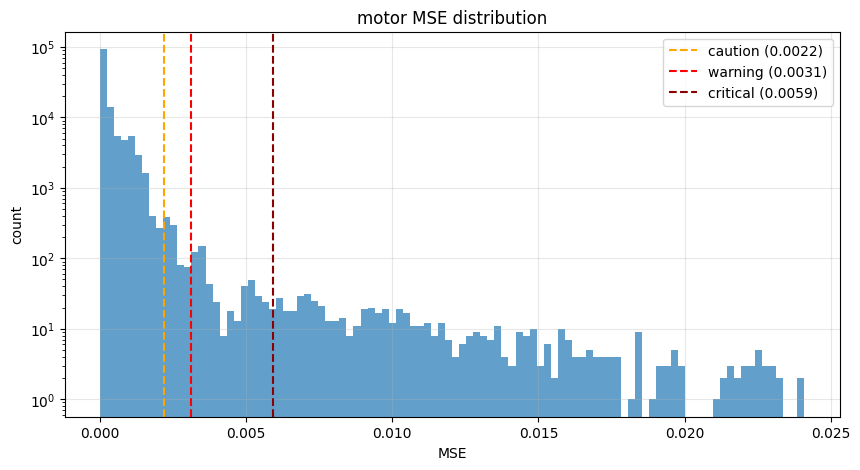

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mse_scores, bins=100, alpha=0.7)
for lvl, color in [('caution', 'orange'), ('warning', 'red'), ('critical', 'darkred')]:
    ax.axvline(thresholds[lvl], color=color, linestyle='--', label=f'{lvl} ({thresholds[lvl]:.4f})')
ax.set_xlabel('MSE'); ax.set_ylabel('count'); ax.set_title(f'{SELECTED_DOMAIN} MSE distribution')
ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3); plt.show()


### 5-11. 피처별 재구성 오차 threshold (스케일 공간)

In [56]:
per_feature_thresholds = {}
for j, fname in enumerate(feature_cols):
    if not scoring_mask[j]:
        continue
    col_err = sq_err[:, j]
    mu, sd = float(col_err.mean()), float(col_err.std())
    per_feature_thresholds[fname] = {
        'mean': round(mu, 8), 'std': round(sd, 8),
        'caution':  round(mu + 2 * sd, 8),
        'warning':  round(mu + 3 * sd, 8),
        'critical': round(mu + 6 * sd, 8),
    }
print(f'{len(per_feature_thresholds)}개 피처 계산됨')
pd.DataFrame(per_feature_thresholds).T


6개 피처 계산됨


,mean,std,caution,warning,critical
motor_power_kw,0.000212,0.000970,0.002151,0.003120,0.006029
motor_temperature_c,0.000871,0.002862,0.006595,0.009457,0.018044
wire_to_water_efficiency,0.000306,0.001067,0.002439,0.003506,0.006706
pump_rpm,0.000210,0.001441,0.003092,0.004533,0.008855
rpm_slope,0.000081,0.000898,0.001876,0.002773,0.005466
temp_slope_c_per_s,0.000322,0.000993,0.002308,0.003300,0.006278


### 5-12. 타깃 기준 프로파일

각 타깃의 평균 ±1σ 구간을 정상 subset으로 간주 → related features의 sigma 라인 계산 (프론트 overlay용).

In [57]:
target_reference_profiles = build_target_reference_profiles(df_agg, target_dict)
print(f'프로파일 타깃: {list(target_reference_profiles.keys())}')
# 한 타깃만 자세히
first_target = list(target_reference_profiles.keys())[0]
print(f'\n=== {first_target} ===')
print(json.dumps(target_reference_profiles[first_target], indent=2, ensure_ascii=False, default=str))


프로파일 타깃: ['motor_current_a', 'rpm_stability_index']

=== motor_current_a ===
{
  "한글명": "모터 전류",
  "target_threshold_basis": "target_caution_band_1sigma",
  "target_lines": {
    "normal": 3.324,
    "caution": {
      "lower": 0.0002,
      "upper": 6.6478
    },
    "warning": {
      "lower": -3.3237,
      "upper": 9.9716
    },
    "critical": {
      "lower": -6.6475,
      "upper": 13.2954
    },
    "std": 3.3238,
    "training_min": 0.0,
    "training_max": 7.8466
  },
  "normal_sample_count": 43028,
  "related_feature_lines": {
    "motor_power_kw": {
      "normal": 2.0766,
      "caution": {
        "lower": 1.9353,
        "upper": 2.2179
      },
      "warning": {
        "lower": 1.7941,
        "upper": 2.3592
      },
      "critical": {
        "lower": 1.6528,
        "upper": 2.5004
      },
      "std": 0.1413,
      "training_min": 0.4132,
      "training_max": 2.2114,
      "한글명": "모터 전력"
    },
    "motor_temperature_c": {
      "normal": 34.77,
      "caution"

### 5-13. SHAP 아티팩트 payload 조립

`train.py`가 디스크에 저장하는 `{domain}_shap.json`과 동일 구조. 프론트 beeswarm 렌더용.

In [58]:
shap_targets_payload = {}
n_features_per_target = {}
for target_name, sv in shap_vals_dict.items():
    X_bg = X_bg_dict[target_name]
    sv_arr = np.asarray(sv)
    mean_abs = np.abs(sv_arr).mean(axis=0)
    order_idx = np.argsort(mean_abs)[::-1]
    features_list = list(X_bg.columns)
    shap_targets_payload[target_name] = {
        'features':       features_list,
        'mean_abs_shap':  mean_abs.tolist(),
        'feature_order':  [features_list[i] for i in order_idx],
        'shap_values':    sv_arr.tolist(),
        'feature_values': X_bg.values.tolist(),
    }
    n_features_per_target[target_name] = len(features_list)
    print(f'{target_name}: features={len(features_list)} samples={sv_arr.shape[0]}')

shap_payload = {
    'targets': shap_targets_payload,
    'n_samples': int(next(iter(shap_vals_dict.values())).shape[0]) if shap_vals_dict else 0,
    'n_features': n_features_per_target,
    'computed_at': datetime.utcnow().isoformat() + 'Z',
}
print(f'\nn_samples: {shap_payload["n_samples"]}')
print(f'computed_at: {shap_payload["computed_at"]}')


motor_current_a: features=24 samples=200
rpm_stability_index: features=25 samples=200

n_samples: 200
computed_at: 2026-04-22T07:42:16.719907Z


### 5-14. 최종 config 미리보기

`{domain}_config.json`에 저장될 내용. 여기서는 저장하지 않고 구조만 확인.

In [59]:
config_preview = {
    'model_name': SELECTED_DOMAIN,
    'features': feature_cols,
    'scoring_features': scoring_features,
    'target_feature_map': target_dict,
    'threshold_caution': thresholds['caution'],
    'threshold_warning': thresholds['warning'],
    'threshold_critical': thresholds['critical'],
    'per_feature_thresholds': per_feature_thresholds,
    'metrics': {
        'train_loss': [float(l) for l in history.history['loss']],
        'val_loss':   [float(l) for l in history.history['val_loss']],
        'final_mse_mean': thresholds['mean'],
    },
    'feature_stds': X_train_ae.std().to_dict(),
    'target_reference_profiles': target_reference_profiles,
}
# 요약만
print(f'model_name: {config_preview["model_name"]}')
print(f'features:   {len(config_preview["features"])}')
print(f'scoring:    {len(config_preview["scoring_features"])}')
print(f'targets:    {list(config_preview["target_feature_map"].keys())}')
print(f'epochs:     {len(config_preview["metrics"]["train_loss"])}')
print(f'thresholds c/w/e: {config_preview["threshold_caution"]:.6f} / '
      f'{config_preview["threshold_warning"]:.6f} / {config_preview["threshold_critical"]:.6f}')


model_name: motor
features:   10
scoring:    6
targets:    ['motor_current_a', 'rpm_stability_index']
epochs:     29
thresholds c/w/e: 0.002196 / 0.003127 / 0.005921


저장하려면:

In [60]:
# 아래 2줄 주석 해제하면 실제 저장 (기존 파일 덮어쓰기 주의)
# from utils import save_model_artifacts
# save_model_artifacts(autoencoder, scaler, config_preview, SELECTED_DOMAIN, str(PROJECT_ROOT / 'models'))
print('저장하려면 위 셀의 주석을 풀어주세요')


저장하려면 위 셀의 주석을 풀어주세요


---

## 6. 4개 도메인 일괄 실행 (train.py와 동일)

위에서 한 도메인을 확인했다면, 이제 4개 전부 순회하면서 실제로 학습·저장까지 진행.

⚠️ **SHAP × 4 + AE 학습 × 4 → 수십 분** 걸릴 수 있습니다. 필요 없으면 이 셀은 건너뛰세요.

⚠️ `save_model_artifacts` 호출 라인의 주석을 풀어야 실제 `models/{domain}_*` 파일이 갱신됩니다. 기본값은 **저장 안 함 / 로그만**.

In [61]:
def run_full_pipeline(system_name, target_dict, df_raw, save=False):
    print(f'\n{"=" * 60}')
    print(f'[{system_name.upper()}] 파이프라인 시작')
    print(f'{"=" * 60}')

    # Step 1-2: window + clean
    target_cols = list(target_dict.keys())
    df_agg, df_interpret = step1_prepare_window_data(
        df_raw, window_method='sliding', target_cols=target_cols
    )
    df_clean = step2_clean_and_drop_collinear_dynamic(
        df_agg, corr_threshold=0.85, protected_cols=target_cols
    )

    # Step 3-4: SHAP + select
    ensemble_lists, importance_results, shap_vals_dict, X_bg_dict = run_shap_ensemble(
        df_clean, target_dict, top_ratio=0.25
    )
    selected = ensemble_lists['robust'] if ensemble_lists['robust'] else ensemble_lists['union']
    X_train_ae = df_clean[selected].copy()

    # inject
    X_train_ae, inj_vip = inject_vip_features(X_train_ae, df_interpret, VIP_FEATURES)
    mandatory_sensors = SENSOR_MANDATORY.get(system_name, [])
    X_train_ae, inj_sensor = inject_vip_features(X_train_ae, df_agg, mandatory_sensors)
    print(f'VIP 주입: {inj_vip}')
    print(f'센서 주입: {inj_sensor}')
    print(f'최종 X_train_ae: {X_train_ae.shape}')

    # scale + AE fit
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X_train_ae)
    autoencoder = build_autoencoder(input_dim=X_scaled.shape[1])
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = autoencoder.fit(
        X_scaled, X_scaled, epochs=100, batch_size=64,
        validation_split=0.2, callbacks=[early_stopping], verbose=0,
    )

    # thresholds
    reconstructed = autoencoder.predict(X_scaled, verbose=0)
    sq_err = np.power(X_scaled - reconstructed, 2)
    feature_cols = X_train_ae.columns.tolist()
    scoring_mask = actionable_feature_mask(feature_cols)
    if scoring_mask.sum() == 0:
        scoring_mask = np.ones(len(feature_cols), dtype=bool)
    scoring_features = [f for f, k in zip(feature_cols, scoring_mask) if k]
    mse_scores = np.mean(sq_err[:, scoring_mask], axis=1)
    thresholds = calculate_sigma_thresholds(mse_scores, sigma_levels=(2, 3, 6))

    per_feat = {}
    for j, fname in enumerate(feature_cols):
        if not scoring_mask[j]:
            continue
        col_err = sq_err[:, j]
        mu, sd = float(col_err.mean()), float(col_err.std())
        per_feat[fname] = {
            'mean': round(mu, 8), 'std': round(sd, 8),
            'caution':  round(mu + 2 * sd, 8),
            'warning':  round(mu + 3 * sd, 8),
            'critical': round(mu + 6 * sd, 8),
        }

    # profiles
    target_reference_profiles = build_target_reference_profiles(df_agg, target_dict)

    # build config
    config = {
        'model_name': system_name,
        'features': feature_cols,
        'scoring_features': scoring_features,
        'target_feature_map': target_dict,
        'threshold_caution': thresholds['caution'],
        'threshold_warning': thresholds['warning'],
        'threshold_critical': thresholds['critical'],
        'per_feature_thresholds': per_feat,
        'metrics': {
            'train_loss': [float(l) for l in history.history['loss']],
            'val_loss':   [float(l) for l in history.history['val_loss']],
            'final_mse_mean': thresholds['mean'],
        },
        'feature_stds': X_train_ae.std().to_dict(),
        'target_reference_profiles': target_reference_profiles,
    }

    print(f'features={len(feature_cols)} scoring={len(scoring_features)} '
          f'epochs={len(history.history["loss"])} '
          f'thresh c/w/e={thresholds["caution"]:.4f}/{thresholds["warning"]:.4f}/{thresholds["critical"]:.4f}')

    if save:
        from utils import save_model_artifacts
        save_model_artifacts(autoencoder, scaler, config, system_name, str(PROJECT_ROOT / 'models'))
        # SHAP artifact
        shap_targets_payload = {}
        for tname, sv in shap_vals_dict.items():
            X_bg = X_bg_dict[tname]
            sv_arr = np.asarray(sv)
            mean_abs = np.abs(sv_arr).mean(axis=0)
            order_idx = np.argsort(mean_abs)[::-1]
            feats = list(X_bg.columns)
            shap_targets_payload[tname] = {
                'features': feats,
                'mean_abs_shap': mean_abs.tolist(),
                'feature_order': [feats[i] for i in order_idx],
                'shap_values': sv_arr.tolist(),
                'feature_values': X_bg.values.tolist(),
            }
        shap_payload = {
            'targets': shap_targets_payload,
            'n_samples': int(next(iter(shap_vals_dict.values())).shape[0]) if shap_vals_dict else 0,
            'n_features': {k: len(v['features']) for k, v in shap_targets_payload.items()},
            'computed_at': datetime.utcnow().isoformat() + 'Z',
        }
        shap_path = PROJECT_ROOT / 'models' / f'{system_name}_shap.json'
        with open(shap_path, 'w') as f:
            json.dump(shap_payload, f)
        print(f'💾 저장: {shap_path}')

    tf.keras.backend.clear_session()
    return config, history

# 실제 실행하려면 SAVE=True (models/ 폴더 덮어씀)
SAVE = False
all_configs = {}
for sys_name, tgt_dict in subsystem_targets.items():
    cfg, hist = run_full_pipeline(sys_name, tgt_dict, df_raw_full, save=SAVE)
    all_configs[sys_name] = cfg

print('\n' + '=' * 60)
print('완료')
print('=' * 60)
for name, cfg in all_configs.items():
    print(f'{name}: {len(cfg["features"])} features → threshold crit = {cfg["threshold_critical"]:.6f}')



[MOTOR] 파이프라인 시작
⏳ [Step 1] 파생변수 생성 및 SLIDING 윈도우 집계 시작...
  -> 집계 완료! (집계 데이터: (129599, 38), 해석용 데이터: (129599, 17))

🧹 [Step 2] 데이터 정제 및 다중공선성(상관계수 > 0.85) 변수 동적 제거 시작...
  -> 동적 중복/노이즈 변수 11개 제거 완료!
  -> 삭제된 컬럼: ['wire_to_water_efficiency', 'flow_roll_mean_10', 'differential_pressure_kpa', 'pid_error_ec', 'pressure_flow_ratio', 'relative_humidity_pct', 'pressure_roll_mean_10', 'drain_ec_ds_m', 'suction_pressure_kpa', 'flow_diff', 'pressure_trend_10']
  -> 남은 피처 수: 27
[motor_current_a] 전체 129,599행 | RF샘플 상한=50,000 | 클러스터 상한=200
  -> RF 학습용 50,000행 랜덤 샘플링 완료 (원본 129,599행)
  -> K-Means 배경 압축 중...
  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (6개) 피처 선정 완료

[rpm_stability_index] 전체 129,599행 | RF샘플 상한=50,000 | 클러스터 상한=200
  -> RF 학습용 50,000행 랜덤 샘플링 완료 (원본 129,599행)
  -> K-Means 배경 압축 중...
  -> 대표 패턴 200개 추출 완료. SHAP 계산 시작...
  -> 상위 25.0% (6개) 피처 선정 완료

🏆 Multi-Target SHAP Ensemble 결과 요약
1. 교집합 (모두에서 중요): 2개
2. 투표(Voting, 2개 이상 타겟에서 중요): 2개  <-- [AutoEncoder 추천]
3. 합집합 (전체 풀): 10개
V

---

## 7. 참고

- 실제 모델 학습·저장은 `src/train.py`를 CLI로 실행하는 것이 정본 — 이 노트북은 **진단·실험용 재현**입니다.
- SHAP 결과 (shap_vals_dict, X_bg_dict)는 프론트 beeswarm 렌더용. 스펙: [`docs/SHAP_BEESWARM_FRONTEND.md`](../docs/SHAP_BEESWARM_FRONTEND.md)
- API 응답 구조: [`docs/INFERENCE_API.md`](../docs/INFERENCE_API.md)
- 컬럼 사전: [`docs/COLUMNS_REFERENCE.md`](../docs/COLUMNS_REFERENCE.md)


In [62]:
우리는 막힘 현상을 예측하기 위해서 오토인코더를 사용했는데, 

인코딩되는 방법을 학습하는 거고,
차원을 줄이고,차원을 복원시켜가지고, 디코딩 결국에는 고차원의 데이터를 저차원으로 으로 변환시키는 건데,
우리가 쓰는 데이터들은 3차원이다. 3차원의 데이터들을 2차원의 평면 데이터로 차원을 축소를 시킵니다.
(인코딩 과정이.) manifold 학습하는 방법이라고 하는 거
인코딩 ㅗ딘거를 디코딩 해서 고대로 출력시키는 것.

이게 무슨 의미가 있겠냐? 라고 생각할 수는 있겠죠.
오토인코더라는 거는 비지도 학습에 활용되는, 모델이다.

방법을 학습시키는 것. 복원 reconstruction. 
정상데이터를 명확히 기준을 정해서 이 데이터를 가지고 매니폴드 방식의 고-> 저 차원 변환 방식을 학습.
정상 > decoding 과정 학습, 비정상 데이테는 decoding tl, reconstruction error를 보여주고, 정상과 ㅏ이가 있다.
라고 

*** 매니폴드 방식의 인코딩 방식
정상데이터를 저차원으로 변환하는

오토인코더 6시그마 -> 시그마  값 범위에 따른 에러 너무 과하면 
정상범주 




SyntaxError: invalid decimal literal (743419518.py, line 5)